<a href="https://colab.research.google.com/github/DecioVdA/ProveComm/blob/main/Modelli/RandomForest_RidDispo_Fasce15min.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Random Forest_RiduzioneDisponibilità

In questo esempio, al posto di analizzare solamente il totale giornaliero della targert feature.
Eliminerò quindi la variabile TransitiFRA dal DataSetAddestramento, moltiplicherò il DataFrame per 96 valori gionralieri, in modo da ottenere per ogni giorno dell'anno un totale di 96 rows, che rappresentano delle fasce orarie di 15 minuti.

Successivamente, importero' all'interno del notebook un'altro dataset relativo ai transiti annulai per scaglioni di 15 minuti.

Effettuero' un merge dei 2 dataset, in modo da poter effettuare una successiva pulizia dei dati e un'encoding delle variabili categoriche.

Per finire, separerò il dataframe in set di training e di test e modellizzerò un modello RandomForest, con target feaute i valori di transito

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import requests
from io import BytesIO
import random
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import seaborn as sns

rd_seed = 42


#### Import dei dataset

In [2]:
url = "https://github.com/DecioVdA/ProveComm/raw/refs/heads/main/DataSetAddestramento.xlsx"
response = requests.get(url)
df = pd.read_excel(BytesIO(response.content))

In [58]:
df_transiti = pd.read_csv("https://raw.githubusercontent.com/DecioVdA/ProveComm/refs/heads/main/data_fascia_oraria15minuti.csv", delimiter=';')

In [5]:
df = df.drop(['TransitiFRA'], axis= 1) # Eliminazione della feature giornaliera.

In [64]:

df_transiti = df_transiti.rename(columns={
    "Année": "Anno",
    "Mois": "Mese",
    "Jour": "Giorno",
    "Fascia_oraria_15m": "FasciaOraria"
})

mappa_mesi_fr = {
    'janvier': 1,
    'fevrier': 2, 'février': 2,
    'mars': 3,
    'avril': 4,
    'mai': 5,
    'juin': 6,
    'juillet': 7,
    'aout': 8, 'août': 8,
    'septembre': 9,
    'octobre': 10,
    'novembre': 11,
    'decembre': 12, 'décembre': 12
}

df_transiti["Mese"] = (
    df_transiti["Mese"]
    .str.normalize("NFKD")
    .str.encode("ascii", "ignore")
    .str.decode("utf-8")
    .str.lower()
)


df_transiti["MeseNumerico"] = df_transiti["Mese"].map(mappa_mesi_fr)

df_transiti["Anno"] = pd.to_numeric(df_transiti["Anno"])
df_transiti["MeseNumerico"] = pd.to_numeric(df_transiti["MeseNumerico"])
df_transiti["Giorno"] = pd.to_numeric(df_transiti["Giorno"])

df_transiti["Data"] = pd.to_datetime({
    "year": df_transiti["Anno"],
    "month": df_transiti["MeseNumerico"],
    "day": df_transiti["Giorno"]
})


df_transiti["GiornoSettimana"] = df_transiti["Data"].dt.dayofweek +1




In [4]:
def espansione_dataFrame(d_frame):
  row_espanse = []
  for idx, row in df.iterrows():
      for fascia in range(1, 97):  # da 1 a 96
          new_row = row.copy()
          new_row["FasciaOraria"] = fascia
          row_espanse.append(new_row)
  df_espanso = pd.DataFrame(row_espanse)
  return df_espanso


df = espansione_dataFrame(df)


In [5]:
df.head()

,Data,GiornoSettimana,Scolastiche_VDA,Scolastiche_FRA,Scolastiche_CH,Festivo_ITA,Festivo_FRA,Festivo_CH,Dispo_TU,Dispo_Fre,FasciaOraria
0,2024-01-01,Lunedi,1,ABC,nullo,FE,FE,FE,1.0,1.0,1
0,2024-01-01,Lunedi,1,ABC,nullo,FE,FE,FE,1.0,1.0,2
0,2024-01-01,Lunedi,1,ABC,nullo,FE,FE,FE,1.0,1.0,3
0,2024-01-01,Lunedi,1,ABC,nullo,FE,FE,FE,1.0,1.0,4
0,2024-01-01,Lunedi,1,ABC,nullo,FE,FE,FE,1.0,1.0,5


In [6]:
df.shape[0]

35136

In [7]:
df.shape[0] == (366*4*24) # 366 giorni di 24 ore moltiplicati per 4 fasce di analisi

True

Import dei dati di transito al dettaglio di 15 minuti e conversione in dataframe.

In [59]:
df_transiti.head()

,Année,Mois,Jour,Fascia_oraria_15m,Transiti
0,2024,janvier,1,00:00:00,6
1,2024,janvier,1,00:15:00,5
2,2024,janvier,1,00:30:00,5
3,2024,janvier,1,00:45:00,19
4,2024,janvier,1,01:00:00,10


In [65]:
df_transiti.head()

,Anno,Mese,Giorno,FasciaOraria,Transiti,MeseNumerico,Data,GiornoSettimana
0,2024,janvier,1,00:00:00,6,1,2024-01-01,1
1,2024,janvier,1,00:15:00,5,1,2024-01-01,1
2,2024,janvier,1,00:30:00,5,1,2024-01-01,1
3,2024,janvier,1,00:45:00,19,1,2024-01-01,1
4,2024,janvier,1,01:00:00,10,1,2024-01-01,1


Dato il periodo di chiusura, ci sono dei valori mancanti. Per esmpio alcuni mesi.


In [25]:
df_transiti.shape[0]

22290

In [26]:
ordine = df_transiti['Mese'].unique()
ordine = np.insert(ordine, 9, ['octobre', 'novembre'])
ordine = ordine[::-1]
fig = px.box(df_transiti, x = 'Transiti', y = 'Mese', color = 'Mese', title = 'Analisi Mensile degli Outliers')
fig.update_yaxes(categoryorder='array', categoryarray=ordine)
fig.show()

In [27]:
df_transiti['FasciaOraria'] = pd.to_timedelta(df_transiti['FasciaOraria'])
df_transiti['FasciaOraria_cat'] = (df_transiti['FasciaOraria'].dt.total_seconds() / 60 / 15).astype(int) + 1
df_transiti = df_transiti.drop(['FasciaOraria'], axis = 1)
df_transiti.head()

,Mese,Giorno,Transiti,FasciaOraria_cat
0,janvier,1,6,1
1,janvier,1,5,2
2,janvier,1,5,3
3,janvier,1,19,4
4,janvier,1,10,5


In [32]:
df_transiti['Mese'] = df_transiti['Mese'].replace({
    'janvier':'gennaio',
    'février':'febbraio',
    'mars':'marzo',
    'avril':'aprile',
    'mai':'maggio',
    'juin':'giugno',
    'juillet':'luglio',
    'août':'agosto',
    'septembre':'settembre',
    'octobre':'ottobre',
    'novembre':'novembre',
    'décembre':'dicembre'
})


In [36]:
mappa_giorni = {
    1:'Lunedi',
    2:'Martedi',
    3:'Mercoledi',
    4:'Giovedi',
    5:'Venerdi',
    6:'Sabato',
    7:'Domenica',
}

mappa_mesi = {
    1:'gennaio',
    2:'febbraio',
    3:'marzo',
    4:'aprile',
    5:'maggio',
    6:'giugno',
    7:'luglio',
    8:'agosto',
    9:'settembre',
    10:'ottobre',
    11:'novembre',
    12:'dicembre'
}

In [38]:
df_transiti['GiornoSettimana'] = df_transiti['Giorno'].map(mappa_giorni)
df['Mese'] = df['Data'].dt.month.map(mappa_mesi)
df['Giorno'] = df['Data'].dt.day
df['GiornoAnno'] = df['Data'].dt.day_of_year
df = df.drop(['Data'], axis=1)


In [39]:
df.head()

,GiornoSettimana,Scolastiche_VDA,Scolastiche_FRA,Scolastiche_CH,Festivo_ITA,Festivo_FRA,Festivo_CH,Dispo_TU,Dispo_Fre,FasciaOraria,Mese,Giorno,GiornoAnno
0,Lunedi,1,ABC,nullo,FE,FE,FE,1.0,1.0,1,gennaio,1,1
0,Lunedi,1,ABC,nullo,FE,FE,FE,1.0,1.0,2,gennaio,1,1
0,Lunedi,1,ABC,nullo,FE,FE,FE,1.0,1.0,3,gennaio,1,1
0,Lunedi,1,ABC,nullo,FE,FE,FE,1.0,1.0,4,gennaio,1,1
0,Lunedi,1,ABC,nullo,FE,FE,FE,1.0,1.0,5,gennaio,1,1


In [45]:
df_transiti['Giorno'].unique()

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31])

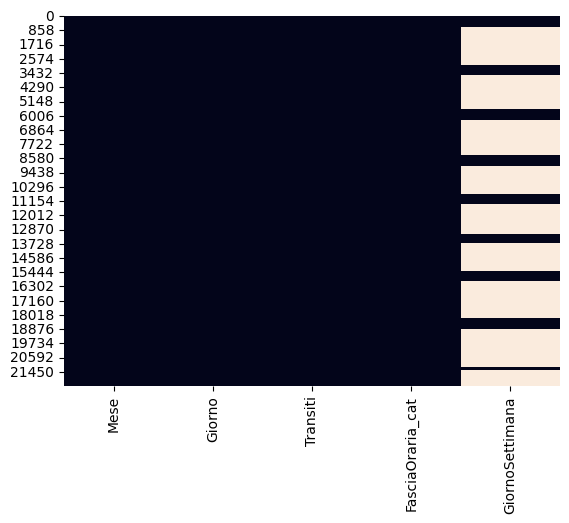

In [41]:
mancanti = df_transiti
sns.heatmap(mancanti.isnull(), cbar=False)
plt.show()

In [ ]:

df_merged = df.merge(
    df_transiti,
    on=["Anno", "mois", "Giorno", "FasciaOraria"],
    how="left"
)

In [ ]:
df_merged.shape[0]

In [ ]:
df_merged.head()

In [ ]:
df_merged = df_merged.drop(['GiornoSettimana_x'], axis = 1)
df_merged = df_merged.drop(['Mese'], axis = 1)
df_merged = df_merged.drop(['Giorno'], axis = 1)
df_merged = df_merged.drop(['GiornoAnno'], axis = 1)
df_merged = df_merged.drop(['Anno'], axis = 1)
df_merged['Scolastiche_VDA'] = df_merged['Scolastiche_VDA'].replace({1: 'Si', 0:'No'})

In [ ]:
df_merged = df_merged.rename(columns={"GiornoSettimana_y": "Giorno"})

In [ ]:
missing_values = df_merged
sns.heatmap(missing_values.isnull(), cbar = False)
plt.show()

Elimino i valori per Dispo_TU = 0

In [ ]:
df_merged = df_merged[df_merged["Dispo_TU"] > 0].copy()
df_merged['Transiti'] = df_merged['Transiti'].fillna(0)
df_merged = df_merged.drop(['Giorno'], axis = 1)

In [ ]:
df_merged.shape[0]

In [ ]:
df_merged.isnull().sum()

In [ ]:
df_merged['FasciaOraria'] = df_merged['FasciaOraria'].astype(str)

In [ ]:
df_merged.info()

In [ ]:
categoriche = ['Scolastiche_VDA','Scolastiche_FRA','Scolastiche_CH','Festivo_ITA', 'Festivo_FRA', 'Festivo_CH', 'FasciaOraria', 'mois']
numeriche = list(set(df_merged.columns)- set(df_merged[categoriche]) - {'Transiti'})

Suddivisone del dataframe in training e test


In [ ]:
X = df_merged.drop(['Transiti'], axis = 1)
y = df_merged['Transiti']

In [ ]:
X_train , X_test, y_train, y_test = train_test_split(X,y, test_size=0.3, random_state=rd_seed)

In [ ]:
encoder = OneHotEncoder().fit(X_train[categoriche])

X_train_cat_enc = encoder.transform(X_train[categoriche]).todense().astype(int)
X_train_cat_enc = pd.DataFrame(X_train_cat_enc, columns = encoder.get_feature_names_out(categoriche), index = X_train.index)

X_test_cat_enc = encoder.transform(X_test[categoriche]).todense().astype(int)
X_test_cat_enc = pd.DataFrame(X_test_cat_enc, columns = encoder.get_feature_names_out(categoriche), index = X_test.index)


In [ ]:
X_train = pd.concat([X_train[numeriche], X_train_cat_enc], axis=1)
X_test = pd.concat([X_test[numeriche], X_test_cat_enc], axis=1)

In [ ]:
model = RandomForestRegressor(random_state = rd_seed)
model.fit(X_train, y_train)

In [ ]:
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

In [ ]:

print("MAE train:", mean_absolute_error(y_train, y_pred_train))
print("MAE test:", mean_absolute_error(y_test, y_pred_test))

print("RMSE train:", mean_squared_error(y_train, y_pred_train))
print("RMSE test:", mean_squared_error(y_test, y_pred_test))

print("R2 train:", r2_score(y_train, y_pred_train))
print("R2 test:", r2_score(y_test, y_pred_test))

In [ ]:
imps = pd.DataFrame()
imps['Variabile'] = X_train.columns
imps['Importanza'] = model.feature_importances_
imps = imps.sort_values('Importanza')
px.bar(imps, x = 'Variabile', y = 'Importanza')